# Unemployment Analysis


## Importing Modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Reading the CSV File

In [2]:
df = pd.read_csv("Unemployment in India.csv")

## Basic Information

In [3]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
df.shape

(768, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [6]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


## We can observe that we are having the null values in common so let us remove them.

In [7]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [8]:
df.dropna(inplace=True)

## Checking Duplicated values

In [9]:
df.duplicated().sum()

np.int64(0)

## Checking the Columns

In [10]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

## Feature Engineering

### Let us split the date into Date , Month , Year .

In [11]:
df['Month'] = df[' Date'].str.split("-").str[1]

In [12]:
df['Year'] = df[' Date'].str.split("-").str[2]

In [13]:
df['Date'] = df[' Date'].str.split("-").str[0]

In [14]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Month,Year,Date
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural,05,2019,31
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural,06,2019,30
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural,07,2019,31
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural,08,2019,31
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural,09,2019,30


## After creating Date , month and year we can drop the Date feature.

In [15]:
df.drop(' Date' , axis=1,inplace=True)

In [16]:
df.head()

,Region,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Month,Year,Date
0,Andhra Pradesh,Monthly,3.65,11999139.0,43.24,Rural,05,2019,31
1,Andhra Pradesh,Monthly,3.05,11755881.0,42.05,Rural,06,2019,30
2,Andhra Pradesh,Monthly,3.75,12086707.0,43.50,Rural,07,2019,31
3,Andhra Pradesh,Monthly,3.32,12285693.0,43.97,Rural,08,2019,31
4,Andhra Pradesh,Monthly,5.17,12256762.0,44.68,Rural,09,2019,30


## We can observe that the frequency is having 2 values that are similar and one ("Monthly")

In [17]:
df[' Frequency'].unique()

array([' Monthly', 'Monthly'], dtype=object)

## As all the values in this feature are same we can drop this feature.

In [18]:
df.drop(' Frequency',axis=1,inplace=True)

In [19]:
df.head()

,Region,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Month,Year,Date
0,Andhra Pradesh,3.65,11999139.0,43.24,Rural,05,2019,31
1,Andhra Pradesh,3.05,11755881.0,42.05,Rural,06,2019,30
2,Andhra Pradesh,3.75,12086707.0,43.50,Rural,07,2019,31
3,Andhra Pradesh,3.32,12285693.0,43.97,Rural,08,2019,31
4,Andhra Pradesh,5.17,12256762.0,44.68,Rural,09,2019,30


## We are having Rural Area and Urban Area

In [20]:
df['Area'].unique()

array(['Rural', 'Urban'], dtype=object)

<Axes: xlabel=' Estimated Employed'>

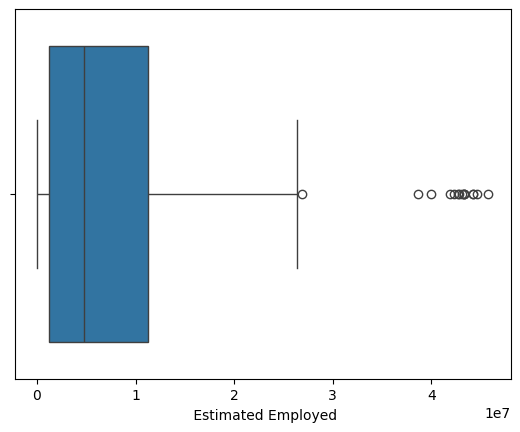

In [21]:
sns.boxplot(x=df[' Estimated Employed'])

### The above boxplot explains us about the distribution of data in the column.

<Axes: xlabel=' Estimated Unemployment Rate (%)'>

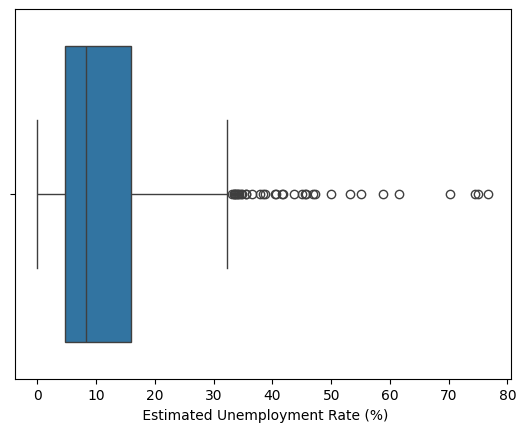

In [22]:
sns.boxplot(x=df[' Estimated Unemployment Rate (%)'])

### The above boxplot explains us about the Estimated Unemployment Rate  in the column.

<Axes: xlabel=' Estimated Labour Participation Rate (%)'>

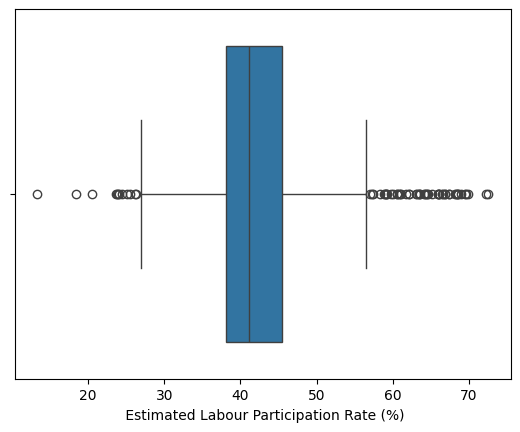

In [23]:
sns.boxplot(x=df[' Estimated Labour Participation Rate (%)'])

### The above boxplot explains us about the distribution of Estimated Labour Participation in the column.

In [24]:
df.head()

,Region,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Month,Year,Date
0,Andhra Pradesh,3.65,11999139.0,43.24,Rural,05,2019,31
1,Andhra Pradesh,3.05,11755881.0,42.05,Rural,06,2019,30
2,Andhra Pradesh,3.75,12086707.0,43.50,Rural,07,2019,31
3,Andhra Pradesh,3.32,12285693.0,43.97,Rural,08,2019,31
4,Andhra Pradesh,5.17,12256762.0,44.68,Rural,09,2019,30


In [25]:
df.columns

Index(['Region', ' Estimated Unemployment Rate (%)', ' Estimated Employed',
       ' Estimated Labour Participation Rate (%)', 'Area', 'Month', 'Year',
       'Date'],
      dtype='object')

In [26]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


<Axes: xlabel=' Estimated Employed', ylabel='Count'>

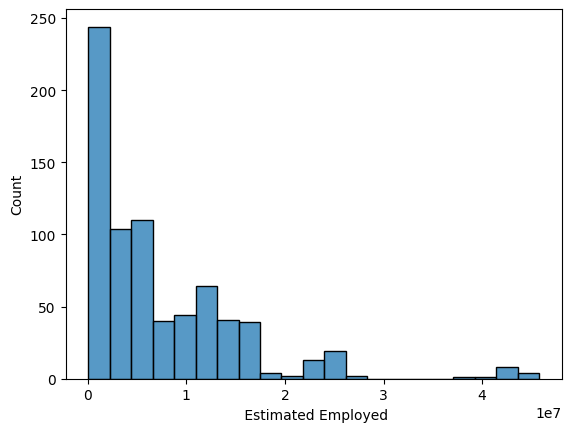

In [27]:
sns.histplot(x=df[' Estimated Employed'])

### The above hisplot clearly defines that we are having a lot of people who are Unemployed.

<Axes: xlabel=' Estimated Employed'>

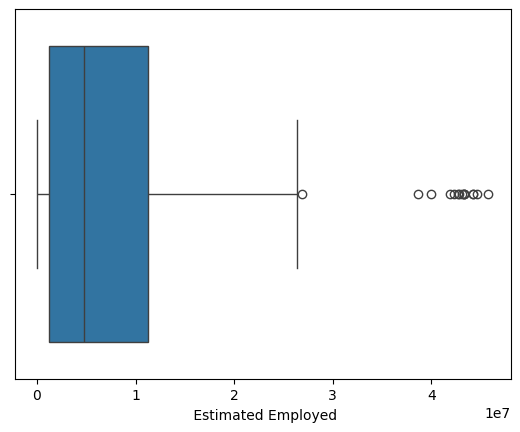

In [28]:
sns.boxplot(x=df[' Estimated Employed'])


<Axes: xlabel=' Estimated Labour Participation Rate (%)', ylabel='Count'>

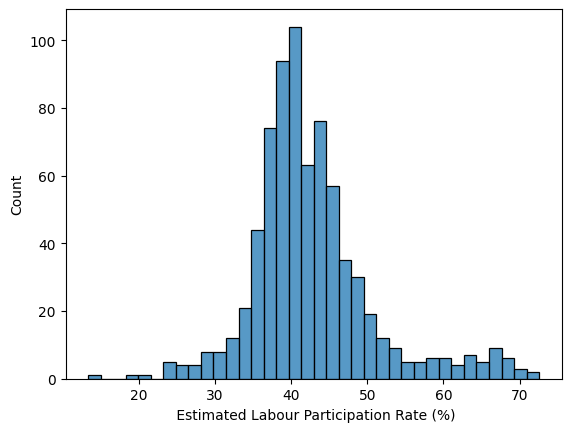

In [29]:
sns.histplot(x=df[' Estimated Labour Participation Rate (%)'])

### The Estimated Labour Participation feature is having data that is Uniform.

<Axes: xlabel=' Estimated Unemployment Rate (%)', ylabel='Count'>

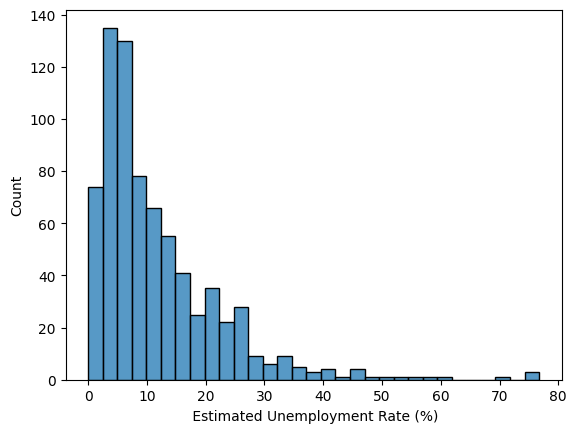

In [30]:
sns.histplot(x=df[' Estimated Unemployment Rate (%)'])

### The above graph really defines that Estimated Unemployment Rate is Really High. 

<Axes: xlabel=' Estimated Unemployment Rate (%)'>

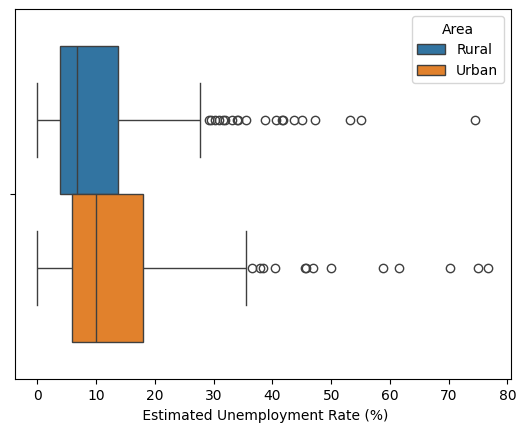

In [31]:
sns.boxplot(x=df[' Estimated Unemployment Rate (%)'],hue=df['Area'])

### We can observe that the Estimated Unemployment Rate in urban areas is High compared to Urban.

<Axes: xlabel='Month', ylabel=' Estimated Unemployment Rate (%)'>

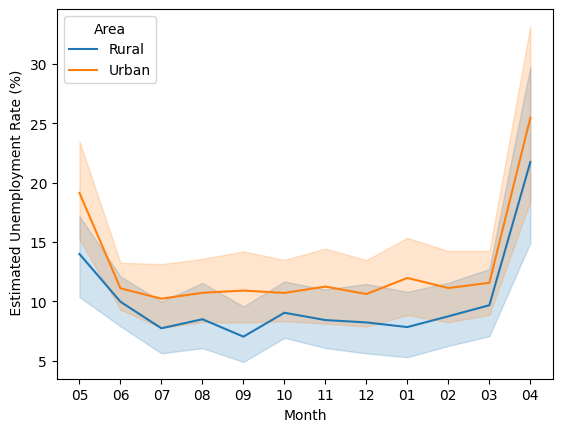

In [32]:
sns.lineplot(x=df['Month'] , y=df[' Estimated Unemployment Rate (%)'] ,hue=df['Area'])

### In the beginning the Unemployment Rate decreased and after few months it Started increasing again.

<Axes: xlabel='Year', ylabel=' Estimated Unemployment Rate (%)'>

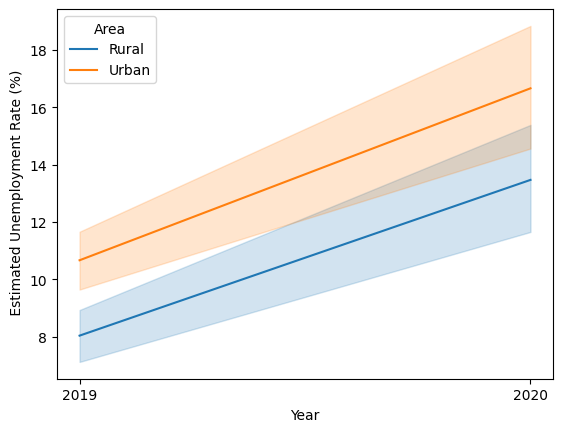

In [33]:
sns.lineplot(x=df['Year'] , y=df[' Estimated Unemployment Rate (%)'], hue=df['Area'])


### The Estimated Unemploymnt Rate had increased when it comes from 2019 to 2020.

<Axes: xlabel='Area', ylabel=' Estimated Employed'>

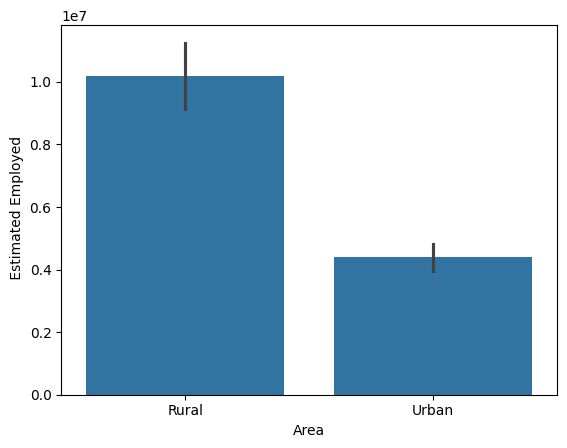

In [34]:
sns.barplot(x=df['Area'] , y=df[' Estimated Employed'])

### The above bar plot clearly defines that the Rural people are having Highly Estimated Employed people.

<Axes: xlabel=' Estimated Unemployment Rate (%)', ylabel='Region'>

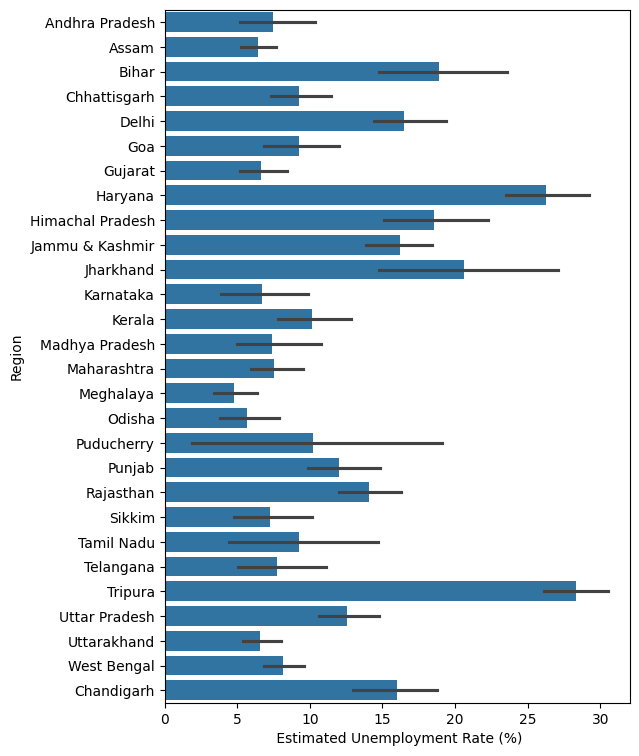

In [39]:
plt.figure(figsize=(6,9))
sns.barplot(y=df['Region'] , x=df[' Estimated Unemployment Rate (%)'])

### The above Barplot Shows us the Unemployment Rate among Different States.We are having Tripura as the Highest Unemployment State and Meghalaya as the lowest Unemployment State.

<Axes: xlabel=' Estimated Unemployment Rate (%)', ylabel='Region'>

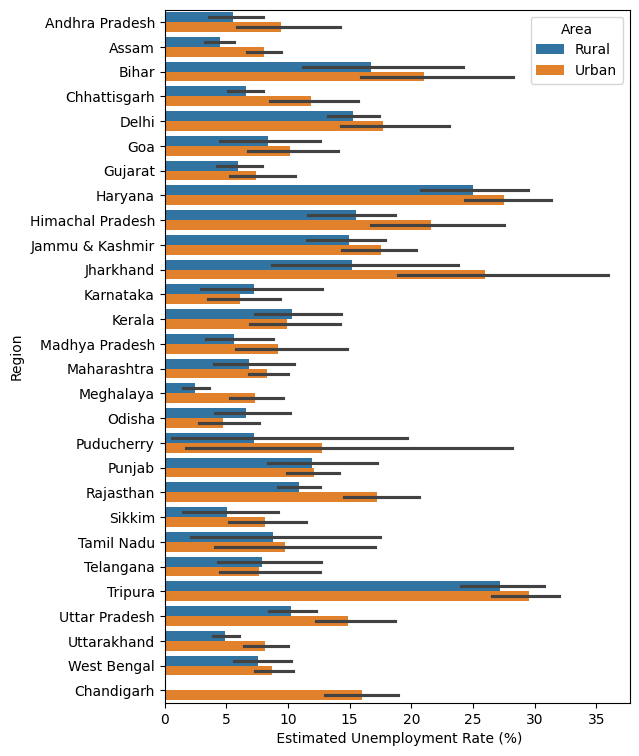

In [40]:
plt.figure(figsize=(6,9))
sns.barplot(y=df['Region'] , x=df[' Estimated Unemployment Rate (%)'],hue=df['Area'])

<Axes: >

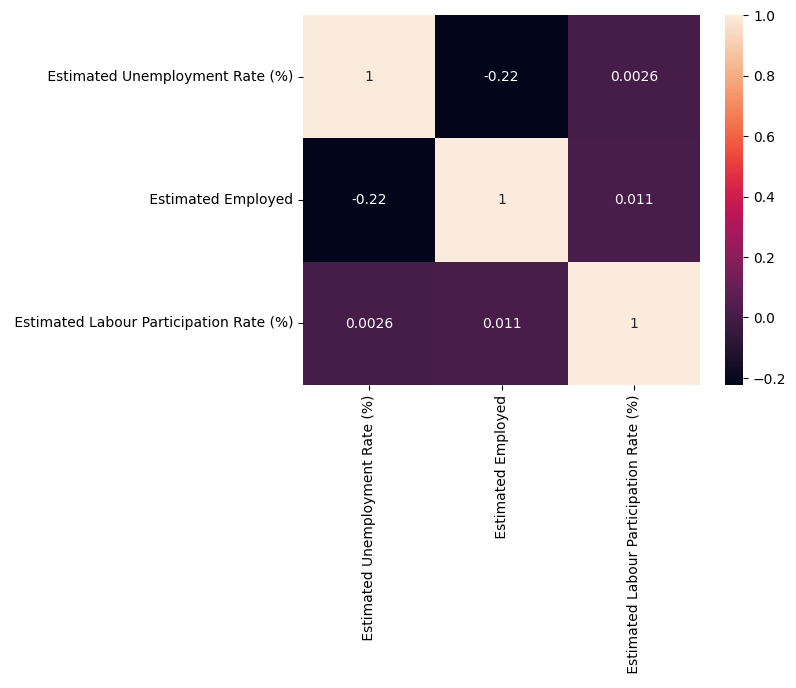

In [37]:
sns.heatmap(df.corr(numeric_only=True) , annot=True)

### We can observe the above Correlation HeatMap of all the Numeric Values.